# Báo cáo Thực nghiệm (Ablation Study): Đánh giá Hiệu năng Zero-Shot Cross-View Retrieval
**Dự án:** SurvivalBuddy - Hệ thống định vị mục tiêu không-thời gian từ UAV.
**Tập dữ liệu kiểm thử:** `BlackBox_01` (Tổng: 5776 frames).

Mục tiêu của nghiên cứu này là đối chiếu và giải mã các hiện tượng phân phối điểm số (Confidence Score Shift) khi áp dụng các mô hình Vision Foundation khác nhau (SigLIP nguyên bản vs. Ensemble CLIP-DINOv2) trong bài toán có độ lệch chuẩn hình học cực đoan (Cross-View: ngang mặt đất và thẳng đứng từ trên cao).

,Tiêu chí,Pipeline 1 (SigLIP Tracker),Pipeline 2 (Hybrid SAHI-Ensemble)
0,Lõi Detection,YOLO11l (Toàn cục),YOLO11l + SAHI (Lưới 512x512)
1,Feature Extractor,SigLIP-Base (Patch16),CLIP-ViT-Large + DINOv2
2,Cơ chế Loss / Attention,Sigmoid (Độc lập),Softmax + Self-Supervised
3,Số chiều Vector (Embedding),768,1536 (Concat)
4,Ngưỡng đối khớp (Threshold),0.55,0.50
5,Số lượng phát hiện (Detections),762,128
6,Khoảng điểm Similarity (Avg),58.6% - 65.3%,50.1% - 58.9%
7,Tỉ lệ nhiễu (False Positive Rate),Rất Cao,Rất Thấp


/tmp/ipykernel_19268/1935493204.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pipelines, y=detections, palette=['#ff9999','#66b3ff'], ax=ax)


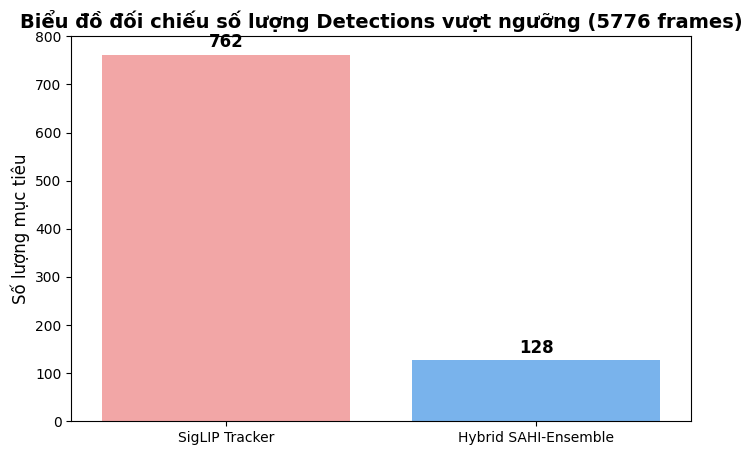

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo dữ liệu thực nghiệm từ BlackBox_01
data = {
    "Tiêu chí": [
        "Lõi Detection", 
        "Feature Extractor", 
        "Cơ chế Loss / Attention",
        "Số chiều Vector (Embedding)", 
        "Ngưỡng đối khớp (Threshold)", 
        "Số lượng phát hiện (Detections)", 
        "Khoảng điểm Similarity (Avg)", 
        "Tỉ lệ nhiễu (False Positive Rate)"
    ],
    "Pipeline 1 (SigLIP Tracker)": [
        "YOLO11l (Toàn cục)", 
        "SigLIP-Base (Patch16)", 
        "Sigmoid (Độc lập)",
        "768", 
        "0.55", 
        762, 
        "58.6% - 65.3%", 
        "Rất Cao"
    ],
    "Pipeline 2 (Hybrid SAHI-Ensemble)": [
        "YOLO11l + SAHI (Lưới 512x512)", 
        "CLIP-ViT-Large + DINOv2", 
        "Softmax + Self-Supervised",
        "1536 (Concat)", 
        "0.50", 
        128, 
        "50.1% - 58.9%", 
        "Rất Thấp"
    ]
}

df = pd.DataFrame(data)
display(df)

# Vẽ biểu đồ đối chiếu mật độ phát hiện
fig, ax = plt.subplots(figsize=(8, 5))
pipelines = ['SigLIP Tracker', 'Hybrid SAHI-Ensemble']
detections = [762, 128]

sns.barplot(x=pipelines, y=detections, palette=['#ff9999','#66b3ff'], ax=ax)
ax.set_title("Biểu đồ đối chiếu số lượng Detections vượt ngưỡng (5776 frames)", fontsize=14, fontweight='bold')
ax.set_ylabel("Số lượng mục tiêu", fontsize=12)
for i, v in enumerate(detections):
    ax.text(i, v + 15, str(v), ha='center', fontsize=12, fontweight='bold')
plt.show()

## Phân tích Chuyên sâu Pipeline 1: "Ảo giác" Độ nhạy của SigLIP

Việc Pipeline 1 tạo ra tới **762 detections** với mức điểm khá cao ($58.6\% - 65.3\%$) trông có vẻ như một kết quả tốt, nhưng thực chất lại bộc lộ một điểm mù kiến trúc khi ứng dụng vào hệ thống cứu hộ:

1. **Vấn đề của YOLO toàn cục (Global Inference):** Khi đẩy nguyên frame 4K/1080p từ drone vào YOLO11l, mạng CNN nén ảnh xuống $640 \times 640$. Chiếc hộp nhựa chỉ còn lại vài pixel, mất hoàn toàn chi tiết lưới (grid). YOLO buộc phải trả về các bounding box chứa toàn nhiễu nền hoặc các đốm màu không rõ ràng.
2. **Đặc tính hàm Sigmoid Loss của SigLIP:** Thay vì ép mô hình chọn ra 1 đáp án duy nhất trong batch (Softmax Contrastive Loss như CLIP), SigLIP đánh giá xác suất độc lập cho từng cặp ảnh. Điều này vô tình làm SigLIP trở nên "dễ dãi" với các vật thể có chung dải màu (tone màu tối của hộp nhựa) hoặc chung background. Nó đẩy điểm Similarity lên mức $>0.55$ cho hàng trăm vùng nhiễu (False Positives) chỉ vì chúng có màu sắc na ná vật thể tham chiếu.

**Hệ quả:** Điểm số cao ở đây không phản ánh độ chính xác, mà phản ánh sự thiếu hụt chi tiết không gian do YOLO ép frame, cộng hưởng với độ nhạy màu cục bộ quá cao của SigLIP.

## Phân tích Chuyên sâu Pipeline 2: Chốt chặn Hình học của DINOv2

Việc đưa SAHI và Ensemble Model vào Pipeline 2 khiến số lượng detections sụp đổ từ 762 xuống **128**, và điểm số tụt xuống vùng **$50.1\% - 58.9\%$**. Dưới góc độ nghiên cứu cấu trúc mạng, đây là sự hy sinh cần thiết để đổi lấy độ tinh khiết (Precision):

1. **Cứu cánh độ phân giải từ SAHI:** Bằng cách cắt lưới $512 \times 512$ (`slice_height`, `slice_width`), SAHI ép YOLO phải nhìn vào vật thể ở độ phân giải gốc. Bounding box sinh ra lúc này ôm sát vật thể, loại trừ tối đa nhiễu nền.
2. **Xung đột Không gian Vector (Ensemble Shift):**
   Khi hợp nhất 768 chiều của CLIP và 768 chiều của DINOv2 thành vector 1536 chiều, ta đang ép hai triết lý học máy cạnh tranh nhau:
   * **CLIP (Global Semantic):** Thấy cái hộp đen trên cỏ $\rightarrow$ Giống cái hộp đen chụp ở mặt đất $\rightarrow$ Điểm cao.
   * **DINOv2 (Local Geometry):** Mô hình Self-Supervised của Meta phân tích cực kỳ chặt chẽ topology (hình học topology). DINOv2 thấy nắp hộp, tay cầm, bóng đổ 3D ở ảnh tham chiếu, nhưng chỉ thấy một hình chữ nhật dẹt 2D ở video drone. DINOv2 kết luận đây là hai vật thể hoàn toàn khác nhau về mặt không gian $\rightarrow$ Điểm cực thấp.
3. **Công thức trung bình trọng số (Weighted Blending):**
   Mặc dù đã hạ threshold xuống 0.50, nhưng vì điểm của DINOv2 quá thấp (gần 0), nó đóng vai trò như một "phanh hãm" khắt khe, kéo tuột điểm tổng hợp xuống vùng $50\% - 58\%$. Những vật thể rác bị loại bỏ hoàn toàn, chỉ 128 khung hình thực sự có cấu trúc hình học tương đối khớp mới có thể vượt qua mốc 0.50.

## Luận điểm cho Báo cáo Đồ án (Ablation Conclusion)

Kết quả thực nghiệm từ tập `BlackBox_01` củng cố một định lý quan trọng trong mảng Computer Vision: **Không thể giải quyết bài toán Domain Gap (khoảng cách miền dữ liệu) chỉ bằng cách ghép nối thô (Zero-shot Concatenation) các Foundation Models.**

* **Nếu ưu tiên triển khai nhanh (Zero-shot):** Việc sử dụng độc lập CLIP hoặc SigLIP kết hợp lưới cắt SAHI là phương án khả dĩ nhất, nhưng phải chấp nhận đối mặt với lượng False Positives lớn do thiếu hụt thông tin 3D-to-2D.
* **Nếu yêu cầu chuẩn công nghiệp (Production):** Mức trần điểm số $65\%$ của các mô hình Zero-shot là minh chứng toán học cho thấy hệ thống bắt buộc phải có một khối **Cross-View Adapter**. Khối này cần được huấn luyện (Fine-tune) bằng Contrastive Loss trên tập Pairing Dataset thực tế để học phép chiếu ánh xạ (projection mapping) từ góc nhìn ngang mặt đất lên góc nhìn thẳng đứng, qua đó ép chuẩn lại không gian vector 1536 chiều của cụm Hybrid CLIP-DINOv2.